# Menguji Kontribusi Fitur Forecasting PM2.5 dengan Ablation Study

Notebook ini digunakan untuk melakukan **ablation study** terhadap model **best LightGBM** yang sebelumnya diperoleh dari tahap hyperparameter tuning.

Tujuan utama notebook ini adalah mengetahui seberapa besar kontribusi setiap **grup fitur** terhadap performa forecasting PM2.5 pada tiga horizon prediksi:

| Horizon | Target Prediksi |
|---:|---|
| H6 | PM2.5 6 jam ke depan |
| H12 | PM2.5 12 jam ke depan |
| H24 | PM2.5 24 jam ke depan |

Pendekatan ablation study dilakukan dengan cara:

1. Melatih model baseline menggunakan **seluruh fitur**.
2. Menghapus **satu grup fitur** pada satu waktu.
3. Melatih ulang model dengan skema validasi yang sama.
4. Membandingkan MAE setelah fitur dihapus dengan MAE baseline.

Interpretasi utamanya adalah:

| Kondisi | Makna |
|---|---|
| MAE naik setelah fitur dihapus | Grup fitur tersebut penting dan membantu model |
| MAE turun setelah fitur dihapus | Grup fitur tersebut kemungkinan kurang membantu atau mengandung noise |
| MAE hampir tidak berubah | Kontribusi grup fitur relatif kecil |

Dengan demikian, notebook ini tidak hanya mengevaluasi performa model, tetapi juga membantu menentukan fitur mana yang layak dipertahankan dan fitur mana yang dapat dipertimbangkan untuk dihapus pada dataset modeling berikutnya.

## Alur Eksperimen Ablation Study

Notebook ini menjalankan ablation study secara bertahap untuk setiap horizon prediksi.

Alur prosesnya dapat diringkas sebagai berikut:

```text
Dataset H6 / H12 / H24
        ↓
Load best params LightGBM dari outputs_phase2/
        ↓
Buat walk-forward validation 4 fold
        ↓
Latih baseline dengan semua fitur
        ↓
Kelompokkan fitur berdasarkan jenisnya
        ↓
Hapus satu grup fitur
        ↓
Latih ulang LightGBM dengan fitur tersisa
        ↓
Hitung perubahan MAE terhadap baseline
        ↓
Simpan hasil ablation dan visualisasi
```

Validasi yang digunakan tetap berbasis waktu dengan pendekatan **walk-forward validation**. Strategi ini penting karena data PM2.5 merupakan data time series, sehingga validation harus berada setelah periode training secara kronologis.

Notebook juga menggunakan **purge gap** sesuai horizon. Artinya, terdapat jarak antara akhir data training dan awal data validation. Purge gap ini membantu mengurangi risiko kebocoran informasi karena target dibuat dengan menggeser PM2.5 ke masa depan.

Secara metodologis, notebook ini menjawab pertanyaan:

> Jika satu kelompok fitur dihapus, apakah performa model menjadi lebih buruk, tetap sama, atau justru membaik?

## Kelompok Fitur yang Diuji

Ablation study pada notebook ini membagi fitur menjadi beberapa kelompok. Setiap kelompok akan dihapus satu per satu untuk melihat dampaknya terhadap performa model.

| Grup Fitur | Contoh Kolom | Makna |
|---|---|---|
| `pm25_lags` | `pm25_lag_1`, `pm25_lag_6`, `pm25_lag_24` | Nilai PM2.5 pada waktu sebelumnya |
| `pm25_roll` | `pm25_roll_mean_*`, `pm25_roll_std_*` | Statistik rolling PM2.5 |
| `pm25_diff` | `pm25_diff_1`, `pm25_diff_24` | Perubahan PM2.5 antarwaktu |
| `weather_current` | `temperature_2m`, `rain`, `surface_pressure` | Kondisi cuaca saat ini |
| `weather_lags` | `temperature_2m_lag_*`, `rain_lag_*` | Kondisi cuaca pada waktu sebelumnya |
| `weather_roll` | `rain_roll_*`, `wind_speed_10m_roll_*` | Statistik rolling cuaca |
| `wind_features` | `wind_u`, `wind_v` | Komponen vektor angin |
| `pollutant_aux_current` | `pm10_work`, `so2_work`, `co_work` | Polutan pendukung saat ini |
| `pollutant_aux_lags` | `pm10_work_lag_*`, `no2_work_lag_*` | Lag polutan pendukung |
| `missing_flags` | `pm25_missing_flag`, `pm10_missing_flag` | Penanda nilai yang awalnya missing |
| `temporal_basic` | `hour_num`, `dayofweek`, `month`, `is_weekend` | Fitur waktu dasar |
| `temporal_cyclical` | `hour_sin`, `hour_cos`, `month_sin`, `month_cos` | Encoding siklik waktu |
| `season_flags` | `season_dry_flag` | Penanda musim kering |
| `station_identity` | `station_id`, `station_slug_*` | Identitas stasiun |
| `station_history_profile` | `station_hour_mean_pm25`, `station_month_mean_pm25` | Profil historis PM2.5 per stasiun |

Pembagian grup fitur ini penting agar analisis tidak hanya melihat fitur secara individual, tetapi juga melihat kontribusi berdasarkan kelompok informasi. Misalnya, kita dapat menilai apakah fitur cuaca, fitur waktu, fitur stasiun, atau fitur historis PM2.5 lebih berpengaruh terhadap performa model.

## Output Ablation dan Perannya dalam Feature Pruning

Notebook ini menghasilkan beberapa output utama:

| Output | Fungsi |
|---|---|
| `ablation_results.csv` | Ringkasan hasil ablation per horizon dan grup fitur |
| `outputs_ablation/ablation_results_by_fold.csv` | Detail hasil ablation per fold |
| `outputs_ablation/ablation_h6.png` | Visualisasi perubahan MAE untuk horizon 6 jam |
| `outputs_ablation/ablation_h12.png` | Visualisasi perubahan MAE untuk horizon 12 jam |
| `outputs_ablation/ablation_h24.png` | Visualisasi perubahan MAE untuk horizon 24 jam |
| `outputs_ablation_datasets/` | Folder dataset baru hasil penghapusan fitur tertentu |

Hasil ablation digunakan sebagai dasar untuk melakukan **feature pruning**, yaitu menghapus fitur yang tidak membantu atau justru memperburuk performa model.

Namun, keputusan menghapus fitur tidak cukup hanya berdasarkan satu angka. Perlu dilihat juga:

1. Konsistensi hasil antar-fold.
2. Besarnya perubahan MAE.
3. Apakah fitur tersebut penting secara domain knowledge.
4. Apakah penghapusan fitur membuat dataset lebih sederhana.
5. Apakah fitur yang dihapus masih dibutuhkan untuk proses downstream.

Dengan demikian, notebook ini berfungsi sebagai tahap eksperimen untuk menyederhanakan dataset dan mengevaluasi kontribusi setiap kelompok fitur secara lebih sistematis.

## Menyiapkan Konfigurasi, Dataset, dan Validasi Time Series

Cell ini menyiapkan library, konfigurasi eksperimen, path dataset, folder output, serta beberapa fungsi dasar yang digunakan dalam ablation study.

Library utama yang digunakan adalah:

| Library | Fungsi |
|---|---|
| `json` | Membaca best params LightGBM dari file JSON |
| `pathlib.Path` | Mengatur path folder output |
| `numpy` | Operasi numerik |
| `pandas` | Membaca dan mengolah dataset |
| `LightGBM` | Model utama untuk ablation study |
| `mean_absolute_error` | Menghitung MAE sebagai metrik evaluasi |

Konfigurasi utama notebook adalah:

| Konfigurasi | Nilai |
|---|---|
| `SEED` | 42 |
| `N_FOLDS` | 4 |
| `PHASE2_DIR` | `outputs_phase2/` |
| `OUT_DIR` | `outputs_ablation/` |

Dataset input yang digunakan adalah:

| Horizon | File Dataset |
|---:|---|
| H6 | `dataset_h6.csv` |
| H12 | `dataset_h12.csv` |
| H24 | `dataset_h24.csv` |

### Fungsi `load_dataset()`

Fungsi ini membaca dataset horizon, mengubah kolom `datetime` dan `date` menjadi format datetime, lalu mengurutkan data berdasarkan:

```text
datetime
station_slug
```

Pengurutan ini penting karena data bersifat time series dan proses validasi harus mengikuti urutan waktu.

### Fungsi `load_best_lgb_params()`

Fungsi ini membaca best params LightGBM dari folder:

```text
outputs_phase2/
```

File yang dibaca mengikuti format:

```text
best_params_h6.json
best_params_h12.json
best_params_h24.json
```

Parameter ini berasal dari notebook tuning sebelumnya dan digunakan agar ablation study memakai model LightGBM terbaik, bukan parameter default.

### Fungsi `make_walk_forward_folds()`

Fungsi ini membuat **walk-forward validation** dengan 4 fold. Setiap fold memiliki periode training dan validation yang dipisahkan oleh purge gap sesuai horizon.

Purge gap dihitung menggunakan:

```python
train_end = valid_start - pd.Timedelta(hours=horizon)
```

Dengan begitu, untuk H6 ada gap 6 jam, untuk H12 ada gap 12 jam, dan untuk H24 ada gap 24 jam.

### Fungsi `prepare_xy_onehot()`

Fungsi ini memisahkan fitur `X` dan target `y`, lalu mengubah kolom kategorikal menjadi one-hot encoding.

Beberapa kolom dikeluarkan dari fitur:

| Kolom | Alasan |
|---|---|
| Target horizon | Label yang harus diprediksi |
| `datetime` | Kolom waktu mentah |
| `date` | Kolom tanggal mentah |
| `station_name` | Redundan dengan `station_slug` |
| `lokasi` | Kolom teks lokasi |
| `season_simple` | Kolom string musim |

One-hot encoding dilakukan agar `station_slug` dan kolom kategorikal lain dapat digunakan dalam model LightGBM sebagai fitur numerik.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

SEED = 42
N_FOLDS = 4

DATASET_PATHS = {
    6: "dataset_h6.csv",
    12: "dataset_h12.csv",
    24: "dataset_h24.csv",
}

PHASE2_DIR = Path("outputs_phase2")
OUT_DIR = Path("outputs_ablation")
OUT_DIR.mkdir(exist_ok=True)


def load_dataset(path):
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values(["datetime", "station_slug"]).reset_index(drop=True)
    return df


def load_best_lgb_params(horizon):
    fp = PHASE2_DIR / f"best_params_h{horizon}.json"
    if not fp.exists():
        raise FileNotFoundError(f"Best params file tidak ditemukan: {fp}")

    with open(fp, "r") as f:
        obj = json.load(f)

    return obj.get("best_params", {})


def make_walk_forward_folds(df, horizon, n_folds=4, valid_ratio_each=0.10):
    df = df.sort_values(["datetime", "station_slug"]).reset_index(drop=True)
    unique_times = pd.Series(sorted(df["datetime"].dropna().unique()))

    n_times = len(unique_times)
    valid_size = max(1, int(n_times * valid_ratio_each))
    total_valid = n_folds * valid_size

    if total_valid >= n_times:
        raise ValueError("Terlalu banyak fold / valid_ratio terlalu besar.")

    first_valid_start_idx = n_times - total_valid
    folds = []

    for fold_id in range(n_folds):
        valid_start_idx = first_valid_start_idx + fold_id * valid_size
        valid_end_idx = min(valid_start_idx + valid_size - 1, n_times - 1)

        valid_start = pd.Timestamp(unique_times.iloc[valid_start_idx])
        valid_end = pd.Timestamp(unique_times.iloc[valid_end_idx])

        # purge gap sesuai horizon
        train_end = valid_start - pd.Timedelta(hours=horizon)

        train_mask = df["datetime"] < train_end
        valid_mask = (df["datetime"] >= valid_start) & (df["datetime"] <= valid_end)

        folds.append({
            "fold_id": fold_id + 1,
            "train_idx": df.index[train_mask].to_numpy(),
            "valid_idx": df.index[valid_mask].to_numpy(),
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
        })

    return folds


def prepare_xy_onehot(df, target_col):
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "station_name",
        "lokasi",
        "season_simple",
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    X = df[[c for c in df.columns if c not in exclude_cols]].copy()
    y = df[target_col].copy()

    obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=obj_cols, dummy_na=False)

    return X, y

## Mengelompokkan Fitur Berdasarkan Jenis Informasi

Cell ini mendefinisikan fungsi `get_feature_groups()` untuk mengelompokkan fitur ke dalam beberapa grup ablation.

Fungsi ini bekerja dengan cara membaca nama kolom fitur, lalu memasukkannya ke grup tertentu berdasarkan pola nama kolom. Misalnya:

| Pola Nama Kolom | Masuk ke Grup |
|---|---|
| Diawali `pm25_lag_` | `pm25_lags` |
| Diawali `pm25_roll_` | `pm25_roll` |
| Diawali `pm25_diff_` | `pm25_diff` |
| Diawali `rain_lag_` atau `temperature_2m_lag_` | `weather_lags` |
| Diawali `rain_roll_` atau `wind_speed_10m_roll_` | `weather_roll` |
| Diakhiri `_missing_flag` | `missing_flags` |
| Diawali `station_slug_` atau sama dengan `station_id` | `station_identity` |

Pengelompokan ini penting karena ablation study dilakukan pada level grup, bukan pada level fitur satu per satu.

Keuntungan ablation berbasis grup adalah:

1. Lebih mudah diinterpretasikan.
2. Lebih sesuai dengan struktur feature engineering.
3. Mengurangi jumlah eksperimen dibanding menghapus fitur satu per satu.
4. Membantu mengetahui sumber informasi mana yang paling berguna untuk model.

Pada akhir fungsi, grup yang kosong akan dihapus dari dictionary. Dengan demikian, hanya grup yang benar-benar memiliki fitur pada dataset horizon tersebut yang akan diuji.

In [2]:
def get_feature_groups(feature_cols):
    """
    Kelompok fitur berdasarkan prefix / nama kolom.
    Disesuaikan dengan struktur dataset_h6/h12/h24 yang kamu buat.
    """
    groups = {
        "pm25_lags": [],
        "pm25_roll": [],
        "pm25_diff": [],
        "weather_current": [],
        "weather_lags": [],
        "weather_roll": [],
        "wind_features": [],
        "pollutant_aux_current": [],
        "pollutant_aux_lags": [],
        "missing_flags": [],
        "temporal_basic": [],
        "temporal_cyclical": [],
        "season_flags": [],
        "station_identity": [],
        "station_history_profile": [],
    }

    weather_current_cols = {
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
        "surface_pressure",
        "wind_speed_10m",
        "wind_direction_10m",
    }

    temporal_basic_cols = {
        "hour_num",
        "dayofweek",
        "month",
        "day",
        "is_weekend",
        "is_rush_morning",
        "is_rush_evening",
        "is_workhour",
        "has_rain",
    }

    temporal_cyc_cols = {
        "hour_sin", "hour_cos",
        "dow_sin", "dow_cos",
        "month_sin", "month_cos",
    }

    season_cols = {"season_dry_flag"}

    station_history_cols = {
        "station_hour_mean_pm25",
        "station_month_mean_pm25",
        "station_hour_mean_pm25_hist",
        "station_month_mean_pm25_hist",
    }

    for col in feature_cols:
        # PM2.5 features
        if col.startswith("pm25_lag_"):
            groups["pm25_lags"].append(col)
        elif col.startswith("pm25_roll_"):
            groups["pm25_roll"].append(col)
        elif col.startswith("pm25_diff_"):
            groups["pm25_diff"].append(col)

        # weather current
        elif col in weather_current_cols:
            groups["weather_current"].append(col)

        # weather lag
        elif (
            col.startswith("temperature_2m_lag_")
            or col.startswith("relative_humidity_2m_lag_")
            or col.startswith("rain_lag_")
            or col.startswith("surface_pressure_lag_")
            or col.startswith("wind_speed_10m_lag_")
            or col.startswith("wind_u_lag_")
            or col.startswith("wind_v_lag_")
        ):
            groups["weather_lags"].append(col)

        # weather rolling
        elif (
            col.startswith("rain_roll_")
            or col.startswith("temperature_2m_roll_")
            or col.startswith("relative_humidity_2m_roll_")
            or col.startswith("wind_speed_10m_roll_")
        ):
            groups["weather_roll"].append(col)

        # wind features
        elif col in {"wind_u", "wind_v"}:
            groups["wind_features"].append(col)

        # pollutant aux current
        elif col.endswith("_work"):
            groups["pollutant_aux_current"].append(col)

        # pollutant aux lag
        elif (
            col.startswith("pm10_work_lag_")
            or col.startswith("so2_work_lag_")
            or col.startswith("co_work_lag_")
            or col.startswith("o3_work_lag_")
            or col.startswith("no2_work_lag_")
        ):
            groups["pollutant_aux_lags"].append(col)

        # missing flags
        elif col.endswith("_missing_flag"):
            groups["missing_flags"].append(col)

        # temporal basic
        elif col in temporal_basic_cols:
            groups["temporal_basic"].append(col)

        # temporal cyclical
        elif col in temporal_cyc_cols:
            groups["temporal_cyclical"].append(col)

        # season
        elif col in season_cols:
            groups["season_flags"].append(col)

        # station identity (one-hot hasil get_dummies)
        elif col.startswith("station_slug_") or col == "station_id":
            groups["station_identity"].append(col)

        # station history profile
        elif col in station_history_cols:
            groups["station_history_profile"].append(col)

    # buang grup kosong
    groups = {k: v for k, v in groups.items() if len(v) > 0}
    return groups

## Menjalankan Ablation Study untuk H6, H12, dan H24

Cell ini merupakan bagian utama notebook. Di sini, model LightGBM dievaluasi menggunakan seluruh fitur sebagai baseline, kemudian dievaluasi ulang dengan menghapus satu grup fitur pada satu waktu.

### Alur Evaluasi

Untuk setiap horizon, proses yang dilakukan adalah:

1. Membaca dataset horizon.
2. Menentukan target prediksi.
3. Membuat fitur `X` dan target `y`.
4. Mengelompokkan fitur menggunakan `get_feature_groups()`.
5. Membuat 4-fold walk-forward validation.
6. Membaca best params LightGBM dari `outputs_phase2/`.
7. Melatih baseline dengan semua fitur.
8. Menghapus satu grup fitur.
9. Melatih ulang model.
10. Menghitung perubahan MAE terhadap baseline.

Perubahan MAE dihitung dengan rumus:

```text
mae_change = ablated_mae - baseline_mae
```

Interpretasinya:

| Nilai `mae_change` | Makna |
|---:|---|
| Positif | MAE naik, fitur yang dihapus membantu model |
| Negatif | MAE turun, fitur yang dihapus kemungkinan kurang membantu atau noisy |
| Mendekati nol | Pengaruh fitur kecil |

### Ringkasan Baseline MAE

| Horizon | Baseline MAE |
|---:|---:|
| H6 | 4.2161 |
| H12 | 7.0468 |
| H24 | 10.8440 |

Baseline MAE meningkat ketika horizon semakin panjang. Hal ini konsisten dengan notebook sebelumnya, yaitu prediksi 24 jam ke depan lebih sulit dibanding prediksi 6 jam ke depan.

### Hasil Penting Horizon H6

Pada H6, grup fitur yang paling penting adalah:

| Grup Dihapus | MAE Change | Interpretasi |
|---|---:|---|
| `pm25_diff` | +0.3591 | Fitur perubahan PM2.5 sangat penting untuk horizon pendek |
| `pm25_lags` | +0.0210 | Lag PM2.5 masih membantu |
| `station_history_profile` | +0.0165 | Profil historis stasiun memberi tambahan informasi |
| `temporal_cyclical` | +0.0125 | Pola waktu siklik membantu model |
| `pollutant_aux_lags` | +0.0114 | Lag polutan pendukung ikut membantu |

Grup yang jika dihapus justru sedikit memperbaiki performa H6 adalah:

| Grup Dihapus | MAE Change |
|---|---:|
| `weather_roll` | -0.0154 |
| `weather_current` | -0.0071 |
| `pollutant_aux_current` | -0.0042 |

Artinya, pada horizon 6 jam, fitur perubahan PM2.5 jauh lebih penting dibanding fitur cuaca rolling.

### Hasil Penting Horizon H12

Pada H12, fitur yang paling membantu adalah:

| Grup Dihapus | MAE Change | Interpretasi |
|---|---:|---|
| `pm25_diff` | +0.3648 | Fitur perubahan PM2.5 tetap sangat penting |
| `station_history_profile` | +0.0513 | Profil historis stasiun membantu horizon menengah |
| `pm25_lags` | +0.0139 | Lag PM2.5 masih memberi kontribusi |

Namun, beberapa grup justru menurunkan MAE ketika dihapus:

| Grup Dihapus | MAE Change |
|---|---:|
| `station_identity` | -0.0640 |
| `temporal_cyclical` | -0.0627 |
| `temporal_basic` | -0.0610 |
| `missing_flags` | -0.0576 |
| `wind_features` | -0.0522 |

Hasil ini menunjukkan bahwa untuk H12, beberapa fitur identitas dan fitur waktu mungkin menambah noise atau membuat model kurang stabil pada validation fold.

### Hasil Penting Horizon H24

Pada H24, grup yang paling membantu adalah:

| Grup Dihapus | MAE Change | Interpretasi |
|---|---:|---|
| `pm25_roll` | +0.2723 | Rolling PM2.5 sangat penting untuk horizon panjang |
| `station_history_profile` | +0.0391 | Profil historis stasiun masih membantu |
| `pm25_diff` | +0.0053 | Pengaruh perubahan PM2.5 lebih kecil dibanding H6/H12 |

Grup yang jika dihapus justru memperbaiki performa H24 adalah:

| Grup Dihapus | MAE Change |
|---|---:|
| `weather_roll` | -0.0926 |
| `temporal_basic` | -0.0391 |
| `season_flags` | -0.0342 |
| `missing_flags` | -0.0292 |
| `temporal_cyclical` | -0.0276 |
| `weather_lags` | -0.0268 |

Pada horizon 24 jam, rolling PM2.5 menjadi sangat penting, sedangkan rolling weather justru menjadi kandidat fitur yang dapat dihapus.

### Output yang Disimpan

Cell ini menyimpan dua file utama:

```text
ablation_results.csv
outputs_ablation/ablation_results_by_fold.csv
```

File `ablation_results.csv` berisi ringkasan hasil ablation, sedangkan `ablation_results_by_fold.csv` berisi detail MAE setiap fold.

In [3]:
def evaluate_lgbm_cv_with_feature_subset(X, y, folds, params, selected_features):
    fold_rows = []

    for fold in folds:
        X_train = X.iloc[fold["train_idx"]][selected_features].copy()
        y_train = y.iloc[fold["train_idx"]].copy()
        X_valid = X.iloc[fold["valid_idx"]][selected_features].copy()
        y_valid = y.iloc[fold["valid_idx"]].copy()

        model = LGBMRegressor(
            random_state=SEED,
            verbose=-1,
            **params
        )
        model.fit(X_train, y_train)
        pred_valid = model.predict(X_valid)

        mae = mean_absolute_error(y_valid, pred_valid)

        fold_rows.append({
            "fold_id": fold["fold_id"],
            "mae": mae,
            "n_features": len(selected_features),
        })

    fold_df = pd.DataFrame(fold_rows)
    return fold_df


all_ablation_rows = []
all_ablation_fold_rows = []

for horizon, path in DATASET_PATHS.items():
    print(f"\n===== ABLATION H{horizon} =====")
    df_h = load_dataset(path)
    target_col = f"target_pm25_t_plus_{horizon}"

    X, y = prepare_xy_onehot(df_h, target_col)
    feature_cols = X.columns.tolist()
    feature_groups = get_feature_groups(feature_cols)
    folds = make_walk_forward_folds(df_h, horizon=horizon, n_folds=N_FOLDS, valid_ratio_each=0.10)
    best_params = load_best_lgb_params(horizon)

    # baseline all-features
    baseline_fold_df = evaluate_lgbm_cv_with_feature_subset(
        X=X,
        y=y,
        folds=folds,
        params=best_params,
        selected_features=feature_cols
    )
    baseline_mae = baseline_fold_df["mae"].mean()

    all_ablation_rows.append({
        "horizon": horizon,
        "ablation_type": "baseline_all_features",
        "removed_group": "NONE",
        "n_features_before": len(feature_cols),
        "n_features_after": len(feature_cols),
        "n_features_removed": 0,
        "baseline_mae": baseline_mae,
        "ablated_mae": baseline_mae,
        "mae_change": 0.0,
    })

    tmp_baseline = baseline_fold_df.copy()
    tmp_baseline["horizon"] = horizon
    tmp_baseline["removed_group"] = "NONE"
    tmp_baseline["ablation_type"] = "baseline_all_features"
    all_ablation_fold_rows.append(tmp_baseline)

    print(f"Baseline MAE H{horizon}: {baseline_mae:.4f}")

    # remove-one-group ablation
    for group_name, group_features in feature_groups.items():
        selected_features = [f for f in feature_cols if f not in group_features]

        if len(selected_features) == 0:
            print(f"Skip {group_name}: semua fitur habis.")
            continue

        fold_df = evaluate_lgbm_cv_with_feature_subset(
            X=X,
            y=y,
            folds=folds,
            params=best_params,
            selected_features=selected_features
        )

        ablated_mae = fold_df["mae"].mean()
        mae_change = ablated_mae - baseline_mae

        all_ablation_rows.append({
            "horizon": horizon,
            "ablation_type": "remove_one_group",
            "removed_group": group_name,
            "n_features_before": len(feature_cols),
            "n_features_after": len(selected_features),
            "n_features_removed": len(group_features),
            "baseline_mae": baseline_mae,
            "ablated_mae": ablated_mae,
            "mae_change": mae_change,
        })

        tmp = fold_df.copy()
        tmp["horizon"] = horizon
        tmp["removed_group"] = group_name
        tmp["ablation_type"] = "remove_one_group"
        all_ablation_fold_rows.append(tmp)

        print(
            f"Removed {group_name:<25} | "
            f"removed={len(group_features):>3} | "
            f"ablated_mae={ablated_mae:.4f} | "
            f"delta={mae_change:+.4f}"
        )

ablation_results_df = pd.DataFrame(all_ablation_rows).sort_values(
    ["horizon", "ablation_type", "mae_change"],
    ascending=[True, True, False]
).reset_index(drop=True)

ablation_results_by_fold_df = pd.concat(all_ablation_fold_rows, ignore_index=True)

ablation_results_df.to_csv("ablation_results.csv", index=False)
ablation_results_by_fold_df.to_csv(OUT_DIR / "ablation_results_by_fold.csv", index=False)

print("\nSaved: ablation_results.csv")
display(ablation_results_df)


===== ABLATION H6 =====
Baseline MAE H6: 4.2161
Removed pm25_lags                 | removed=  6 | ablated_mae=4.2371 | delta=+0.0210
Removed pm25_roll                 | removed= 16 | ablated_mae=4.2179 | delta=+0.0018
Removed pm25_diff                 | removed=  2 | ablated_mae=4.5752 | delta=+0.3591
Removed weather_current           | removed=  7 | ablated_mae=4.2091 | delta=-0.0071
Removed weather_lags              | removed= 35 | ablated_mae=4.2255 | delta=+0.0094
Removed weather_roll              | removed= 16 | ablated_mae=4.2007 | delta=-0.0154
Removed wind_features             | removed=  2 | ablated_mae=4.2218 | delta=+0.0057
Removed pollutant_aux_current     | removed=  5 | ablated_mae=4.2120 | delta=-0.0042
Removed pollutant_aux_lags        | removed= 25 | ablated_mae=4.2275 | delta=+0.0114
Removed missing_flags             | removed=  6 | ablated_mae=4.2232 | delta=+0.0071
Removed temporal_basic            | removed=  9 | ablated_mae=4.2184 | delta=+0.0022
Removed temporal

,horizon,ablation_type,removed_group,n_features_before,n_features_after,n_features_removed,baseline_mae,ablated_mae,mae_change
0,6,baseline_all_features,NONE,156,156,0,4.216115,4.216115,0.000000
1,6,remove_one_group,pm25_diff,156,154,2,4.216115,4.575208,0.359093
2,6,remove_one_group,pm25_lags,156,150,6,4.216115,4.237127,0.021011
3,6,remove_one_group,station_history_profile,156,154,2,4.216115,4.232611,0.016496
4,6,remove_one_group,temporal_cyclical,156,150,6,4.216115,4.228630,0.012515
5,6,remove_one_group,pollutant_aux_lags,156,131,25,4.216115,4.227544,0.011428
6,6,remove_one_group,weather_lags,156,121,35,4.216115,4.225478,0.009363
7,6,remove_one_group,season_flags,156,155,1,4.216115,4.224078,0.007963
8,6,remove_one_group,station_identity,156,150,6,4.216115,4.223729,0.007614
9,6,remove_one_group,missing_flags,156,150,6,4.216115,4.223181,0.007066


## Visualisasi Dampak Penghapusan Grup Fitur

Cell ini membuat grafik horizontal bar untuk setiap horizon prediksi.

Grafik menampilkan nilai:

```text
MAE Change vs Baseline
```

Untuk setiap grup fitur yang dihapus.

Interpretasi grafik:

| Posisi Bar | Makna |
|---|---|
| Bar ke kanan dari 0 | MAE naik, fitur penting |
| Bar ke kiri dari 0 | MAE turun, fitur kemungkinan noisy |
| Bar dekat 0 | Pengaruh fitur kecil |

Notebook menghasilkan tiga file grafik:

| Horizon | File Output |
|---:|---|
| H6 | `outputs_ablation/ablation_h6.png` |
| H12 | `outputs_ablation/ablation_h12.png` |
| H24 | `outputs_ablation/ablation_h24.png` |

Visualisasi ini memudahkan pembacaan hasil ablation karena kita dapat langsung melihat fitur mana yang paling berdampak terhadap performa model.

Pada grafik H6 dan H12, `pm25_diff` terlihat sebagai grup paling penting karena penghapusannya menyebabkan kenaikan MAE paling besar. Pada H24, `pm25_roll` menjadi grup paling penting karena prediksi satu hari ke depan lebih membutuhkan informasi tren historis dibanding perubahan jangka pendek saja.

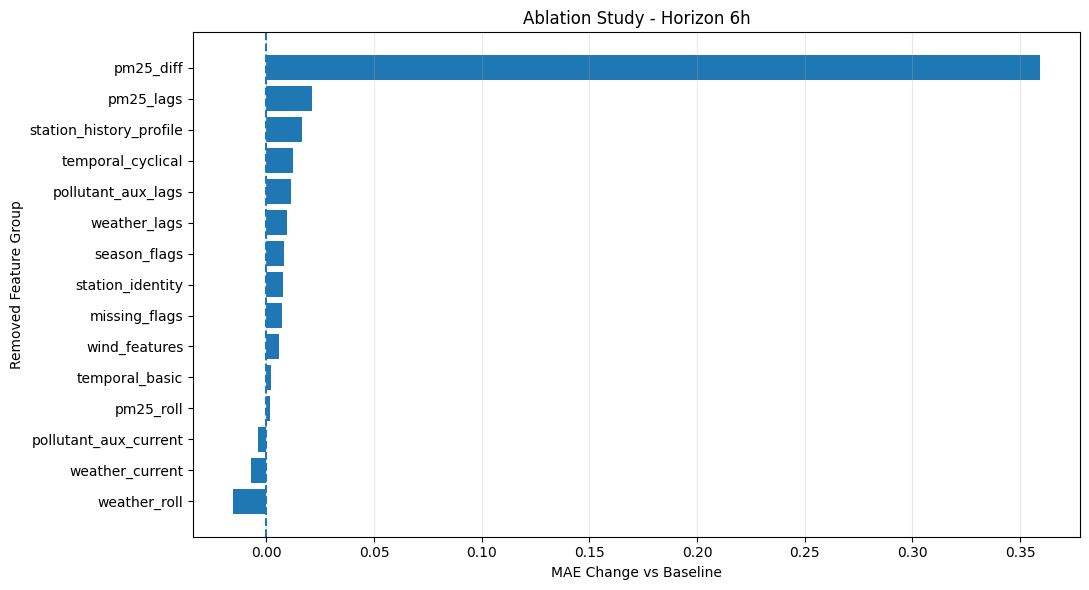

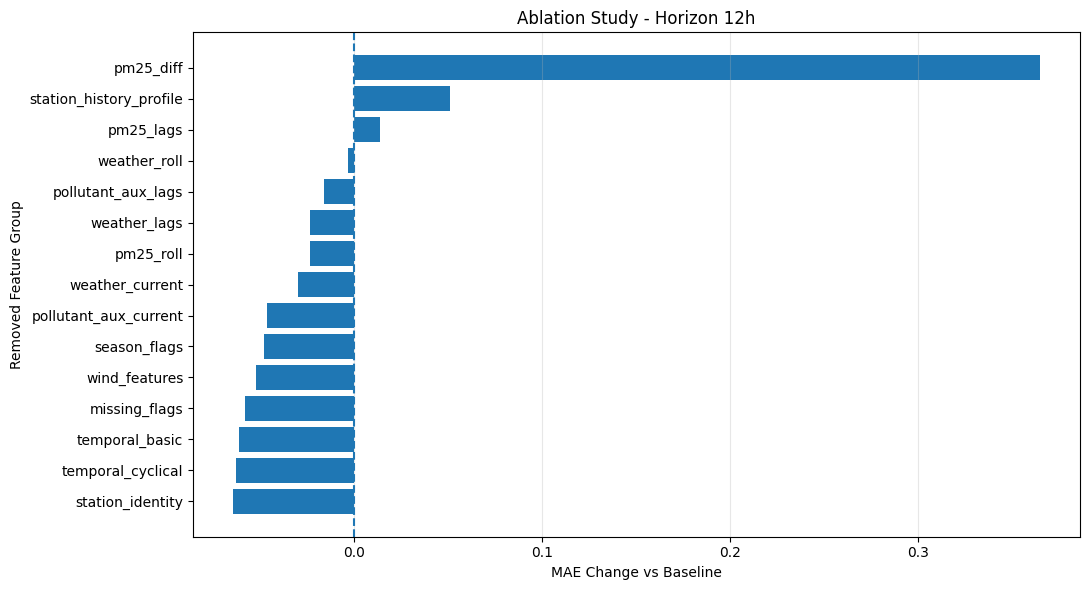

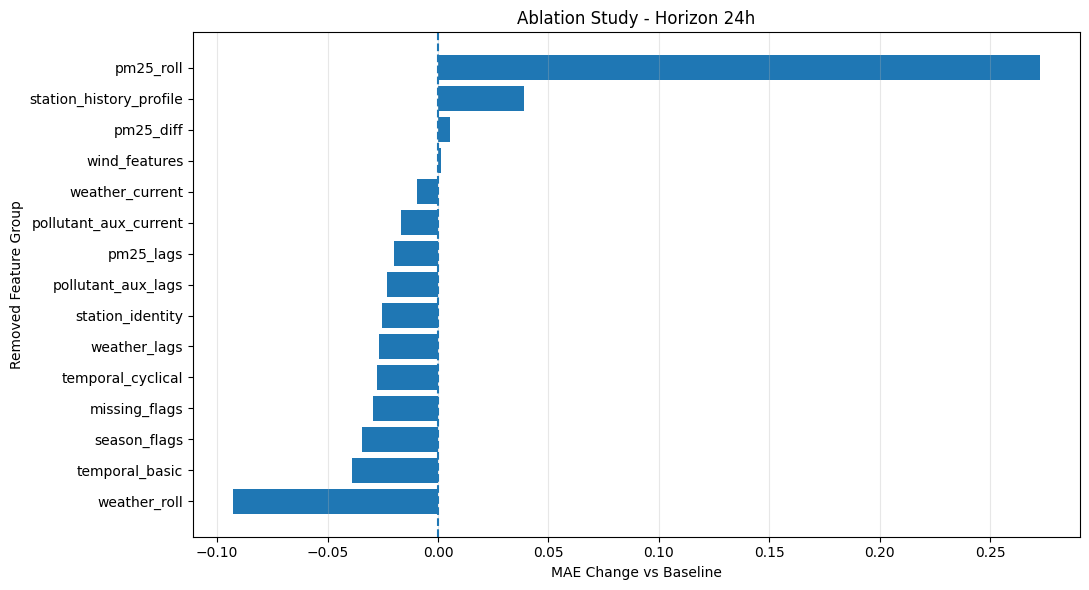

In [4]:
import matplotlib.pyplot as plt

for horizon in sorted(ablation_results_df["horizon"].unique()):
    sub = ablation_results_df[
        (ablation_results_df["horizon"] == horizon) &
        (ablation_results_df["removed_group"] != "NONE")
    ].copy()

    sub = sub.sort_values("mae_change", ascending=False)

    plt.figure(figsize=(11, 6))
    plt.barh(sub["removed_group"], sub["mae_change"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("MAE Change vs Baseline")
    plt.ylabel("Removed Feature Group")
    plt.title(f"Ablation Study - Horizon {horizon}h")
    plt.gca().invert_yaxis()
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"ablation_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

## Membuat Dataset Baru Berdasarkan Hasil Ablation

Cell ini membuat dataset baru hasil feature pruning berdasarkan grup fitur yang ketika dihapus justru memberikan performa lebih baik.

Dataset awal yang digunakan adalah:

| Horizon | Dataset Awal |
|---:|---|
| H6 | `dataset_h6.csv` |
| H12 | `dataset_h12.csv` |
| H24 | `dataset_h24.csv` |

Berdasarkan hasil ablation, grup fitur yang dipilih untuk dihapus adalah:

| Horizon | Grup yang Dihapus | Alasan |
|---:|---|---|
| H6 | `weather_roll` | Menghapus grup ini menurunkan MAE sebesar -0.0154 |
| H12 | `station_identity` | Menghapus grup ini menurunkan MAE sebesar -0.0640 |
| H24 | `weather_roll` | Menghapus grup ini menurunkan MAE sebesar -0.0926 |

Dataset baru disimpan ke folder:

```text
outputs_ablation_datasets/
```

### Output Dataset Baru

| Horizon | File Output | Kolom Dihapus | Shape Baru |
|---:|---|---:|---|
| H6 | `dataset_h6_ablation.csv` | 16 kolom `weather_roll` | `(155850, 139)` |
| H12 | `dataset_h12_ablation.csv` | 2 kolom `station_identity` | `(155820, 154)` |
| H24 | `dataset_h24_ablation.csv` | 16 kolom `weather_roll` | `(155760, 151)` |

Untuk H6 dan H24, kolom yang dihapus berasal dari rolling weather, seperti:

```text
rain_roll_sum_*
temperature_2m_roll_mean_*
relative_humidity_2m_roll_mean_*
wind_speed_10m_roll_mean_*
```

Untuk H12, kolom yang awalnya dihapus adalah:

```text
station_id
station_slug
```

Cell ini juga menyimpan ringkasan kolom yang dihapus ke file:

```text
outputs_ablation_datasets/ablation_dataset_update_summary.csv
```

Catatan penting: dataset hasil ablation ini merupakan kandidat dataset yang lebih ringkas. Namun, sebelum dipakai untuk training final, perlu dicek apakah kolom yang dihapus masih dibutuhkan untuk proses downstream, misalnya grouping, plotting, atau identifikasi stasiun.

In [5]:
from pathlib import Path
import pandas as pd

# =========================
# INPUT DATASET AWAL
# =========================
DATASET_PATHS = {
    6: "dataset_h6.csv",
    12: "dataset_h12.csv",
    24: "dataset_h24.csv",
}

# hasil ablation terbaik per horizon
BEST_ABLATION_REMOVE = {
    6: "weather_roll",
    12: "station_identity",
    24: "weather_roll",
}

OUT_DIR = Path("outputs_ablation_datasets")
OUT_DIR.mkdir(exist_ok=True)

def load_dataset_flexible(path):
    df = pd.read_csv(path)

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

    sort_cols = [c for c in ["datetime", "station_slug"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols).reset_index(drop=True)

    return df

def get_raw_columns_to_remove(df, group_name):
    """
    Mapping dari group ablation -> kolom raw dataset yang dihapus.
    Ini mengikuti struktur dataset_h6/h12/h24 sebelum one-hot encoding.
    """
    remove_cols = []

    if group_name == "weather_roll":
        prefixes = [
            "rain_roll_",
            "temperature_2m_roll_",
            "relative_humidity_2m_roll_",
            "wind_speed_10m_roll_",
        ]
        remove_cols = [c for c in df.columns if any(c.startswith(p) for p in prefixes)]

    elif group_name == "station_identity":
        # ini yang dipakai sebagai identitas stasiun dalam modelling
        candidates = ["station_slug", "station_id"]
        remove_cols = [c for c in candidates if c in df.columns]

    else:
        raise ValueError(f"Group ablation belum dimapping: {group_name}")

    return sorted(remove_cols)

summary_rows = []

for horizon, path in DATASET_PATHS.items():
    df_h = load_dataset_flexible(path)
    remove_group = BEST_ABLATION_REMOVE[horizon]

    cols_to_remove = get_raw_columns_to_remove(df_h, remove_group)
    df_new = df_h.drop(columns=cols_to_remove, errors="ignore").copy()

    out_path = OUT_DIR / f"dataset_h{horizon}_ablation.csv"
    df_new.to_csv(out_path, index=False)

    print(f"[SAVED] {out_path}")
    print(f"  Removed group : {remove_group}")
    print(f"  Removed cols  : {len(cols_to_remove)}")
    if len(cols_to_remove) > 0:
        print(f"  -> {cols_to_remove[:10]}{' ...' if len(cols_to_remove) > 10 else ''}")
    print(f"  New shape     : {df_new.shape}\n")

    for col in cols_to_remove:
        summary_rows.append({
            "horizon": horizon,
            "removed_group": remove_group,
            "removed_column": col,
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "ablation_dataset_update_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("[SAVED SUMMARY]", summary_path)
summary_df.head(20)

[SAVED] outputs_ablation_datasets/dataset_h6_ablation.csv
  Removed group : weather_roll
  Removed cols  : 16
  -> ['rain_roll_sum_12', 'rain_roll_sum_24', 'rain_roll_sum_3', 'rain_roll_sum_6', 'relative_humidity_2m_roll_mean_12', 'relative_humidity_2m_roll_mean_24', 'relative_humidity_2m_roll_mean_3', 'relative_humidity_2m_roll_mean_6', 'temperature_2m_roll_mean_12', 'temperature_2m_roll_mean_24'] ...
  New shape     : (155850, 139)

[SAVED] outputs_ablation_datasets/dataset_h12_ablation.csv
  Removed group : station_identity
  Removed cols  : 2
  -> ['station_id', 'station_slug']
  New shape     : (155820, 154)

[SAVED] outputs_ablation_datasets/dataset_h24_ablation.csv
  Removed group : weather_roll
  Removed cols  : 16
  -> ['rain_roll_sum_12', 'rain_roll_sum_24', 'rain_roll_sum_48', 'rain_roll_sum_6', 'relative_humidity_2m_roll_mean_12', 'relative_humidity_2m_roll_mean_24', 'relative_humidity_2m_roll_mean_48', 'relative_humidity_2m_roll_mean_6', 'temperature_2m_roll_mean_12', 'tem

,horizon,removed_group,removed_column
0,6,weather_roll,rain_roll_sum_12
1,6,weather_roll,rain_roll_sum_24
2,6,weather_roll,rain_roll_sum_3
3,6,weather_roll,rain_roll_sum_6
4,6,weather_roll,relative_humidity_2m_roll_mean_12
5,6,weather_roll,relative_humidity_2m_roll_mean_24
6,6,weather_roll,relative_humidity_2m_roll_mean_3
7,6,weather_roll,relative_humidity_2m_roll_mean_6
8,6,weather_roll,temperature_2m_roll_mean_12
9,6,weather_roll,temperature_2m_roll_mean_24


## Patch Dataset H12 Ablation: Mengembalikan Identitas Stasiun untuk Kebutuhan Downstream

Cell ini melakukan patch khusus pada file:

```text
outputs_ablation_datasets/dataset_h12_ablation.csv
```

Pada cell sebelumnya, grup `station_identity` dipilih untuk dihapus pada H12 karena penghapusannya menurunkan MAE. Kolom yang dihapus adalah:

```text
station_id
station_slug
```

Namun, dalam praktiknya, `station_slug` sering tetap dibutuhkan untuk proses downstream, seperti:

1. Mengurutkan data per stasiun.
2. Membuat visualisasi per stasiun.
3. Melakukan analisis error per lokasi.
4. Menyambungkan prediksi dengan identitas stasiun.
5. Menjaga struktur dataset agar tetap mudah dilacak.

Karena itu, cell ini membaca kembali `dataset_h12.csv` asli dan menambahkan kembali `station_slug` ke `dataset_h12_ablation.csv` berdasarkan urutan baris yang sama.

Jika `station_id` belum ada, cell ini juga menambahkan kembali `station_id`.

Output cell menunjukkan:

```text
[INFO] station_id juga ditambahkan.
[SAVED] outputs_ablation_datasets/dataset_h12_ablation.csv
```

Artinya, setelah patch ini, dataset H12 ablation kembali memiliki `station_slug` dan `station_id`.

Catatan metodologis penting: hasil ablation H12 tetap valid karena evaluasi sebelumnya memang dilakukan dengan menghapus fitur identitas stasiun dari model. Namun, file dataset yang sudah dipatch sekarang mempertahankan identitas stasiun untuk kebutuhan pelacakan data. Jika nanti dataset ini dipakai untuk training ulang, perlu dipastikan apakah `station_slug` dan `station_id` akan dikeluarkan dari fitur model atau tetap digunakan sebagai kolom metadata saja.

In [8]:
import pandas as pd
from pathlib import Path
import shutil

# =========================================================
# PATCH H12 ABLATION:
# Fix station_slug dan station_id berdasarkan station_name
# yang ada di dataset_h12_ablation.csv itu sendiri
# =========================================================

ablation_path = Path("outputs_ablation_datasets/dataset_h12_ablation.csv")

df_abla = pd.read_csv(ablation_path, low_memory=False)

print("Ablation shape:", df_abla.shape)

# ---------------------------------------------------------
# 1. Validasi kolom station_name
# ---------------------------------------------------------
if "station_name" not in df_abla.columns:
    raise ValueError("Kolom station_name tidak ditemukan di dataset_h12_ablation.csv")

print("\nUnique station_name sebelum patch:")
display(df_abla["station_name"].drop_duplicates().sort_values().tolist())

# ---------------------------------------------------------
# 2. Normalisasi station_name
# ---------------------------------------------------------
df_abla["_station_name_norm"] = (
    df_abla["station_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ---------------------------------------------------------
# 3. Mapping berdasarkan station_name
# ---------------------------------------------------------
station_name_to_slug = {
    "dki1 bundaran hi": "dki1-bundaran-hi",
    "dki2 kelapa gading": "dki2-kelapa-gading",
    "dki3 jagakarsa": "dki3-jagakarsa",
    "dki4 lubang buaya": "dki4-lubang-buaya",
    "dki5 kebun jeruk": "dki5-kebun-jeruk",
}

station_name_to_id = {
    "dki1 bundaran hi": 4,
    "dki2 kelapa gading": 5,
    "dki3 jagakarsa": 6,
    "dki4 lubang buaya": 7,
    "dki5 kebun jeruk": 8,
}

# ---------------------------------------------------------
# 4. Backup file lama
# ---------------------------------------------------------
backup_path = ablation_path.with_name(
    ablation_path.stem + "_before_station_name_based_patch.csv"
)

if not backup_path.exists():
    shutil.copy(ablation_path, backup_path)
    print("[BACKUP SAVED]", backup_path)
else:
    print("[BACKUP EXISTS]", backup_path)

# ---------------------------------------------------------
# 5. Overwrite station_slug dan station_id berdasarkan station_name
# ---------------------------------------------------------
df_abla["station_slug"] = df_abla["_station_name_norm"].map(station_name_to_slug)
df_abla["station_id"] = df_abla["_station_name_norm"].map(station_name_to_id)

# ---------------------------------------------------------
# 6. Validasi mapping kosong
# ---------------------------------------------------------
if df_abla["station_slug"].isna().any():
    missing_names = (
        df_abla.loc[df_abla["station_slug"].isna(), "station_name"]
        .drop_duplicates()
        .tolist()
    )
    raise ValueError(f"Ada station_name yang belum masuk mapping slug: {missing_names}")

if df_abla["station_id"].isna().any():
    missing_names = (
        df_abla.loc[df_abla["station_id"].isna(), "station_name"]
        .drop_duplicates()
        .tolist()
    )
    raise ValueError(f"Ada station_name yang belum masuk mapping id: {missing_names}")

df_abla["station_id"] = df_abla["station_id"].astype(int)

# Hapus kolom bantu
df_abla = df_abla.drop(columns=["_station_name_norm"])

# ---------------------------------------------------------
# 7. Validasi hasil patch
# ---------------------------------------------------------
print("\nCrosstab station_name vs station_slug setelah patch:")
display(pd.crosstab(df_abla["station_name"], df_abla["station_slug"]))

print("\nValue counts station_slug setelah patch:")
display(df_abla["station_slug"].value_counts())

print("\nPasangan station_name, station_slug, station_id final:")
display(
    df_abla[["station_name", "station_slug", "station_id"]]
    .drop_duplicates()
    .sort_values(["station_id"])
)

# Pastikan 1 station_name hanya punya 1 station_slug
check_unique = df_abla.groupby("station_name")["station_slug"].nunique()

if (check_unique > 1).any():
    display(check_unique)
    raise ValueError("Masih ada station_name yang punya lebih dari 1 station_slug.")

# ---------------------------------------------------------
# 8. Simpan overwrite
# ---------------------------------------------------------
df_abla.to_csv(ablation_path, index=False)

print("\n[SAVED]", ablation_path)
print("Patch selesai: station_slug dan station_id dibuat ulang dari station_name.")

Ablation shape: (155820, 156)

Unique station_name sebelum patch:


['DKI1 Bundaran HI',
 'DKI2 Kelapa Gading',
 'DKI3 Jagakarsa',
 'DKI4 Lubang Buaya',
 'DKI5 Kebun Jeruk']

[BACKUP SAVED] outputs_ablation_datasets/dataset_h12_ablation_before_station_name_based_patch.csv

Crosstab station_name vs station_slug setelah patch:


station_slug,dki1-bundaran-hi,dki2-kelapa-gading,dki3-jagakarsa,dki4-lubang-buaya,dki5-kebun-jeruk
station_name,,,,,
DKI1 Bundaran HI,31164,0,0,0,0
DKI2 Kelapa Gading,0,31164,0,0,0
DKI3 Jagakarsa,0,0,31164,0,0
DKI4 Lubang Buaya,0,0,0,31164,0
DKI5 Kebun Jeruk,0,0,0,0,31164



Value counts station_slug setelah patch:


station_slug
dki1-bundaran-hi      31164
dki2-kelapa-gading    31164
dki3-jagakarsa        31164
dki4-lubang-buaya     31164
dki5-kebun-jeruk      31164
Name: count, dtype: int64


Pasangan station_name, station_slug, station_id final:


,station_name,station_slug,station_id
0,DKI1 Bundaran HI,dki1-bundaran-hi,4
1,DKI2 Kelapa Gading,dki2-kelapa-gading,5
2,DKI3 Jagakarsa,dki3-jagakarsa,6
3,DKI4 Lubang Buaya,dki4-lubang-buaya,7
4,DKI5 Kebun Jeruk,dki5-kebun-jeruk,8



[SAVED] outputs_ablation_datasets/dataset_h12_ablation.csv
Patch selesai: station_slug dan station_id dibuat ulang dari station_name.


# Struktur Folder dan File Output Notebook

Notebook ini menggunakan input dari dataset modeling dan best params hasil tuning.

Input utama notebook adalah:

```text
dataset_h6.csv
dataset_h12.csv
dataset_h24.csv
```

Notebook juga membaca best params LightGBM dari folder:

```text
outputs_phase2/
```

Struktur output notebook dapat diringkas sebagai berikut:

```text
project/
│
├── dataset_h6.csv
├── dataset_h12.csv
├── dataset_h24.csv
│
├── outputs_phase2/
│   ├── best_params_h6.json
│   ├── best_params_h12.json
│   └── best_params_h24.json
│
├── ablation_results.csv
│
├── outputs_ablation/
│   ├── ablation_results_by_fold.csv
│   ├── ablation_h6.png
│   ├── ablation_h12.png
│   └── ablation_h24.png
│
└── outputs_ablation_datasets/
    ├── dataset_h6_ablation.csv
    ├── dataset_h12_ablation.csv
    ├── dataset_h24_ablation.csv
    └── ablation_dataset_update_summary.csv
```

### Penjelasan File Output

| File atau Folder | Fungsi |
|---|---|
| `ablation_results.csv` | Ringkasan hasil ablation seluruh horizon |
| `outputs_ablation/ablation_results_by_fold.csv` | Detail hasil ablation per fold |
| `outputs_ablation/ablation_h6.png` | Grafik dampak penghapusan fitur pada H6 |
| `outputs_ablation/ablation_h12.png` | Grafik dampak penghapusan fitur pada H12 |
| `outputs_ablation/ablation_h24.png` | Grafik dampak penghapusan fitur pada H24 |
| `outputs_ablation_datasets/dataset_h6_ablation.csv` | Dataset H6 setelah feature pruning |
| `outputs_ablation_datasets/dataset_h12_ablation.csv` | Dataset H12 setelah feature pruning dan patch station identity |
| `outputs_ablation_datasets/dataset_h24_ablation.csv` | Dataset H24 setelah feature pruning |
| `outputs_ablation_datasets/ablation_dataset_update_summary.csv` | Ringkasan kolom yang dihapus dari dataset ablation |

### Ringkasan Hasil Ablation Terpenting

| Horizon | Baseline MAE | Grup Paling Penting | Grup yang Dipilih untuk Dihapus |
|---:|---:|---|---|
| H6 | 4.2161 | `pm25_diff` | `weather_roll` |
| H12 | 7.0468 | `pm25_diff` | `station_identity` |
| H24 | 10.8440 | `pm25_roll` | `weather_roll` |

### Ringkasan Dataset Ablation

| Dataset | Shape Awal | Shape Ablation | Catatan |
|---|---:|---:|---|
| `dataset_h6.csv` | `(155850, 155)` | `(155850, 139)` | Menghapus 16 fitur rolling weather |
| `dataset_h12.csv` | `(155820, 156)` | `(155820, 154)` lalu dipatch | Awalnya menghapus `station_id` dan `station_slug`, lalu identitas stasiun ditambahkan kembali |
| `dataset_h24.csv` | `(155760, 167)` | `(155760, 151)` | Menghapus 16 fitur rolling weather |

Secara keseluruhan, notebook ini menunjukkan bahwa tidak semua fitur hasil feature engineering selalu meningkatkan performa model. Beberapa fitur seperti `pm25_diff` dan `pm25_roll` terbukti penting, sedangkan beberapa grup seperti `weather_roll` pada H6 dan H24 justru dapat dipertimbangkan untuk dihapus agar dataset lebih ringkas dan model lebih stabil.

Output paling penting dari notebook ini adalah:

```text
ablation_results.csv
outputs_ablation/ablation_results_by_fold.csv
outputs_ablation_datasets/dataset_h6_ablation.csv
outputs_ablation_datasets/dataset_h12_ablation.csv
outputs_ablation_datasets/dataset_h24_ablation.csv
```

File-file tersebut dapat digunakan untuk eksperimen lanjutan, khususnya training ulang model dengan dataset hasil feature pruning.